# Retail Sales Time Series Forecasting

**Dataset:** Retail Store Sales Dataset  
**Source:** [Kaggle](https://www.kaggle.com/datasets/manjeetsingh/retaildataset)  
**Author:** Bicher A

## Objective
I build and compare forecasting models to predict weekly retail store 
sales using three joined data sources covering store information, 
sales history, and external features like temperature, fuel price, 
CPI, and holiday flags. 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [6]:
sales = pd.read_csv('sales data-set.csv')
features = pd.read_csv('Features data set.csv')
stores = pd.read_csv('stores data-set.csv')

print("Sales shape:", sales.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

print("\nSales columns:", sales.columns.tolist())
print("Features columns:", features.columns.tolist())
print("Stores columns:", stores.columns.tolist())

print("\nSales sample:")
print(sales.head(3))

Sales shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)

Sales columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
Features columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
Stores columns: ['Store', 'Type', 'Size']

Sales sample:
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False


In [7]:
# Merge sales with stores on Store column
df = sales.merge(stores, on='Store', how='left')

# Merge with features on Store and Date
df = df.merge(features, on=['Store', 'Date'], how='left')

# Handle duplicate IsHoliday columns from merge
if 'IsHoliday_x' in df.columns:
    df['IsHoliday'] = df['IsHoliday_x']
    df = df.drop(columns=['IsHoliday_x', 'IsHoliday_y'])

print("Merged shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSample:")
print(df.head(3))

Merged shape: (421570, 16)
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Sample:
   Store  Dept        Date  Weekly_Sales Type    Size  Temperature  \
0      1     1  05/02/2010      24924.50    A  151315        42.31   
1      1     1  12/02/2010      46039.49    A  151315        38.51   
2      1     1  19/02/2010      41595.55    A  151315        39.93   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   

          CPI  Unemployment  IsHoliday  
0  211.096358         8.106      False  
1  211.242170         8.106       True  
2  211.289143         8.106      False  


In [9]:
# Parse Date column
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')## 1. Exploratory Analysis

I explore overall sales trends over time, the impact of holidays on 
sales, and which stores and departments generate the most revenue.
Understanding these patterns before modelling is essential for making 
good feature engineering decisions.## 1. Exploratory Analysis

I explore overall sales trends over time, the impact of holidays on 
sales, and which stores and departments generate the most revenue.
Understanding these patterns before modelling is essential for making 
good feature engineering decisions.

# Sort chronologically
df = df.sort_values('Date').reset_index(drop=True)

print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Total weeks:", df['Date'].nunique())
print("Total stores:", df['Store'].nunique())
print("Total departments:", df['Dept'].nunique())

# Check missing values
missing = df.isnull().sum()
print("\nMissing values:")
print(missing[missing > 0])

# Fill markdown columns with 0 (no markdown = 0 discount)
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdown_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Fill remaining numeric nulls with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after cleaning:", df.isnull().sum().sum())
print("Cleaned shape:", df.shape)

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Total weeks: 143
Total stores: 45
Total departments: 81

Missing values:
MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64

Missing values after cleaning: 0
Cleaned shape: (421570, 16)


## 1. Exploratory Analysis

I explore overall sales trends over time, the impact of holidays on 
sales, and which stores and departments generate the most revenue.

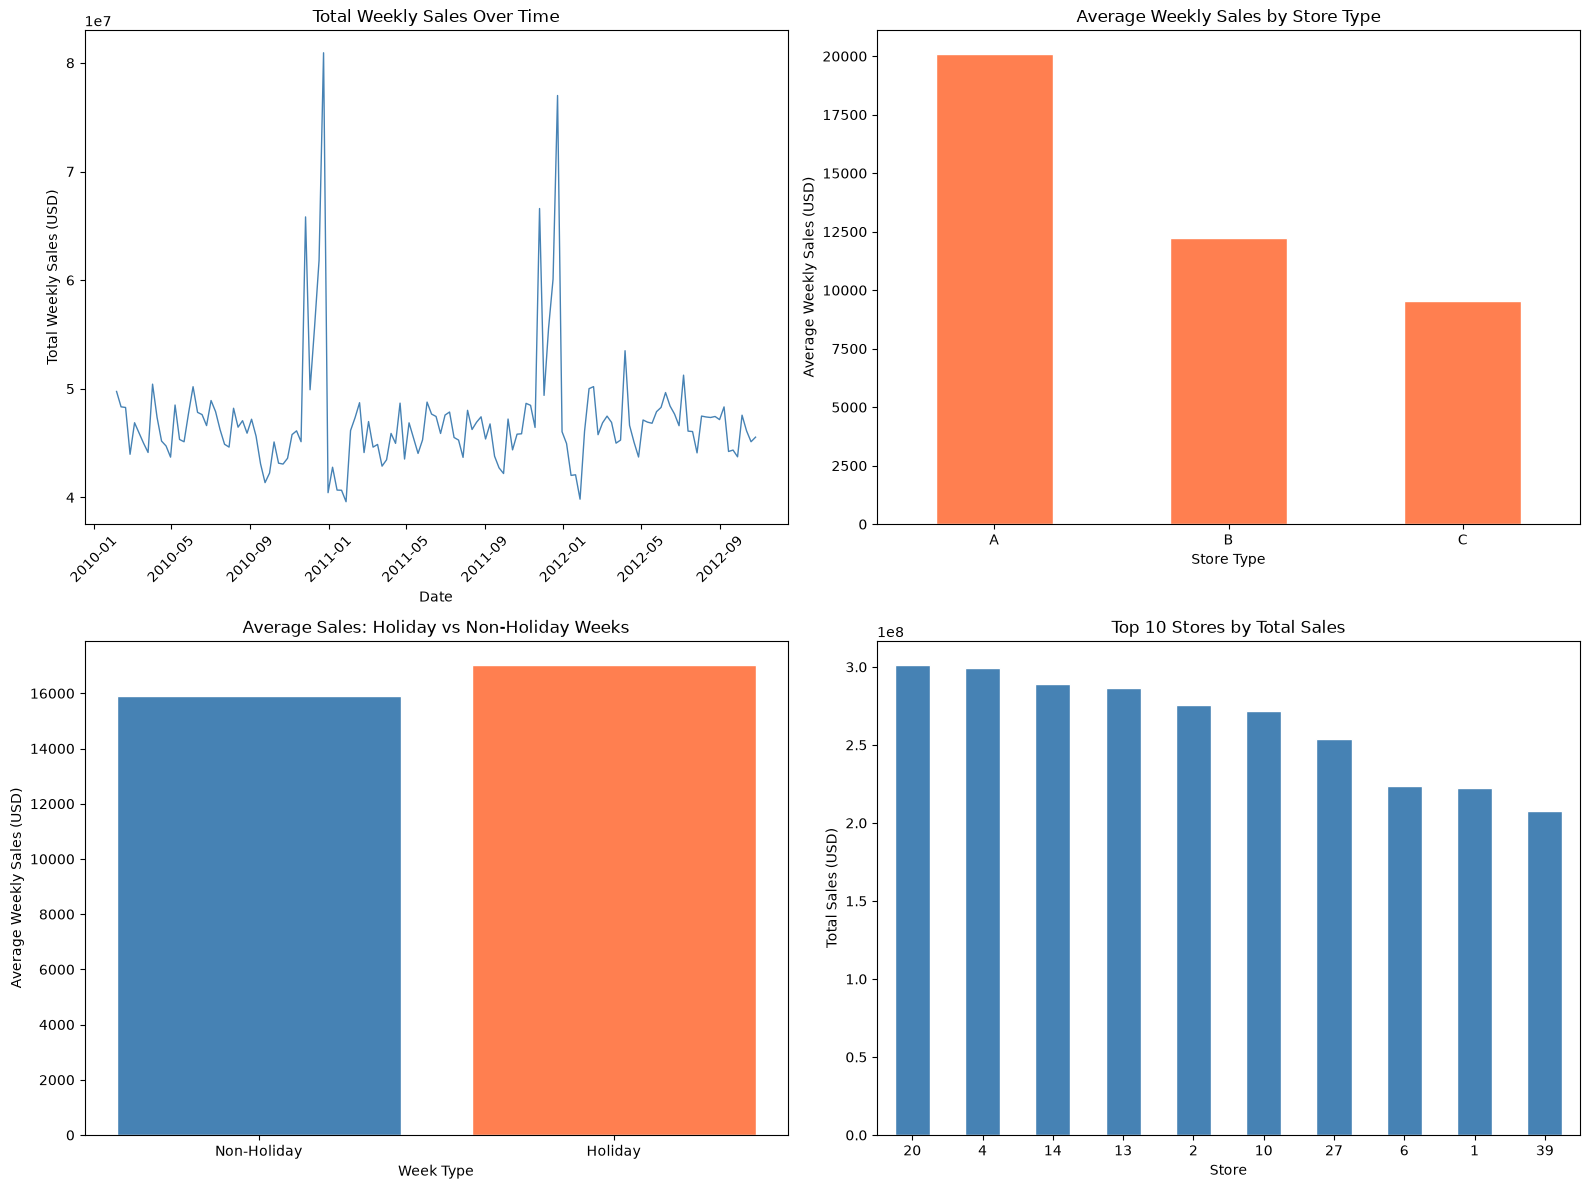

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total weekly sales over time
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
axes[0][0].plot(weekly_sales['Date'], weekly_sales['Weekly_Sales'], 
                color='steelblue', linewidth=1)
axes[0][0].set_title('Total Weekly Sales Over Time')
axes[0][0].set_xlabel('Date')
axes[0][0].set_ylabel('Total Weekly Sales (USD)')
axes[0][0].tick_params(axis='x', rotation=45)

# Sales by store type
df.groupby('Type')['Weekly_Sales'].mean().plot(
    kind='bar', ax=axes[0][1], color='coral', edgecolor='white')
axes[0][1].set_title('Average Weekly Sales by Store Type')
axes[0][1].set_xlabel('Store Type')
axes[0][1].set_ylabel('Average Weekly Sales (USD)')
axes[0][1].tick_params(axis='x', rotation=0)

# Holiday vs non-holiday sales
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()
axes[1][0].bar(['Non-Holiday', 'Holiday'], holiday_sales.values,
               color=['steelblue', 'coral'], edgecolor='white')
axes[1][0].set_title('Average Sales: Holiday vs Non-Holiday Weeks')
axes[1][0].set_xlabel('Week Type')
axes[1][0].set_ylabel('Average Weekly Sales (USD)')

# Top 10 stores by total sales
top_stores = df.groupby('Store')['Weekly_Sales'].sum().nlargest(10)
top_stores.plot(kind='bar', ax=axes[1][1], color='steelblue', edgecolor='white')
axes[1][1].set_title('Top 10 Stores by Total Sales')
axes[1][1].set_xlabel('Store')
axes[1][1].set_ylabel('Total Sales (USD)')
axes[1][1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 2. Feature Engineering for Time Series

I extract time-based features from the Date column that capture 
seasonal and cyclical patterns. 

I also create lag features, the sales from the previous week and 
the same week last year. These are among the most powerful predictors 
in any sales forecasting model because recent history is usually the 
best predictor of the near future.

In [11]:
# Extract time features from Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear

# Convert IsHoliday to integer
df['IsHoliday'] = df['IsHoliday'].astype(int)

# Encode Store Type
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

# Lag features - sort first to ensure correct order
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# Previous week sales (lag 1)
df['lag_1_week'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)

# Same week last year (lag 52 weeks)
df['lag_52_weeks'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)

# Rolling mean - 4 week average
df['rolling_4_week_mean'] = df.groupby(
    ['Store', 'Dept'])['Weekly_Sales'].shift(1).rolling(4).mean().reset_index(0, drop=True)

# Drop rows with NaN from lag features
df = df.dropna(subset=['lag_1_week', 'lag_52_weeks', 'rolling_4_week_mean'])

print("Shape after feature engineering:", df.shape)
print("\nNew features added:")
new_features = ['Year', 'Month', 'Week', 'Quarter', 'DayOfYear', 
                'lag_1_week', 'lag_52_weeks', 'rolling_4_week_mean']
print(new_features)

Shape after feature engineering: (261083, 25)

New features added:
['Year', 'Month', 'Week', 'Quarter', 'DayOfYear', 'lag_1_week', 'lag_52_weeks', 'rolling_4_week_mean']


## 3. Chronological Train/Test Split

Unlike standard machine learning, I cannot randomly split time series 
data. Doing so would allow the model to train on future data and predict 
the past, leaking information and producing artificially inflated results.

Instead I split chronologically, training on all data before a cutoff 
date and testing on all data after it. This simulates real deployment 
where the model only ever sees past data when making predictions.

In [12]:
# Define features to use
feature_cols = [
    'Store', 'Dept', 'Type_encoded', 'Size',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'IsHoliday', 'Year', 'Month', 'Week', 'Quarter',
    'lag_1_week', 'lag_52_weeks', 'rolling_4_week_mean'
] + [col for col in df.columns if 'MarkDown' in col]

target_col = 'Weekly_Sales'

# Chronological split - use last year as test set
cutoff_date = '2012-01-01'
train = df[df['Date'] < cutoff_date]
test = df[df['Date'] >= cutoff_date]

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

print("Training period:", train['Date'].min().date(), "to", train['Date'].max().date())
print("Test period:", test['Date'].min().date(), "to", test['Date'].max().date())
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training period: 2011-02-04 to 2011-12-30
Test period: 2012-01-06 to 2012-10-26
Training samples: 136342
Test samples: 124741


## 4. Modelling

I compare three models on this forecasting task:
- **Linear Regression** - a simple baseline that assumes linear 
  relationships between features and sales
- **Random Forest** - an ensemble model that captures non-linear 
  relationships and interactions between features
- **XGBoost** - sequential tree boosting, typically the strongest 
  performer on structured tabular data with engineered features

In [13]:
# Helper function to evaluate models
def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    print(f"\n{'='*45}")
    print(f"{name}")
    print(f"{'='*45}")
    print(f"MAE:  USD {mae:,.0f}")
    print(f"RMSE: USD {rmse:,.0f}")
    print(f"MAPE: {mape:.2f}%")
    
    return mae, rmse, mape

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_mae, lr_rmse, lr_mape = evaluate_model('Linear Regression', y_test, lr_preds)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_mae, rf_rmse, rf_mape = evaluate_model('Random Forest', y_test, rf_preds)

# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_mae, xgb_rmse, xgb_mape = evaluate_model('XGBoost', y_test, xgb_preds)


Linear Regression
MAE:  USD 1,786
RMSE: USD 3,614
MAPE: inf%

Random Forest
MAE:  USD 1,435
RMSE: USD 3,122
MAPE: inf%

XGBoost
MAE:  USD 1,482
RMSE: USD 3,338
MAPE: inf%


In [14]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (USD)': [lr_mae, rf_mae, xgb_mae],
    'RMSE (USD)': [lr_rmse, rf_rmse, xgb_rmse],
    'MAPE (%)': [lr_mape, rf_mape, xgb_mape]
})

results['MAE (USD)'] = results['MAE (USD)'].apply(lambda x: f"{x:,.0f}")
results['RMSE (USD)'] = results['RMSE (USD)'].apply(lambda x: f"{x:,.0f}")
results['MAPE (%)'] = results['MAPE (%)'].apply(lambda x: f"{x:.2f}%")

print(results.to_string(index=False))

            Model MAE (USD) RMSE (USD) MAPE (%)
Linear Regression     1,786      3,614     inf%
    Random Forest     1,435      3,122     inf%
          XGBoost     1,482      3,338     inf%


## 5. Model Evaluation - Visual Comparison

I visualise actual vs predicted sales over time for the best performing 
model. In time series forecasting this chart is the primary deliverable, 
it shows at a glance how closely the model tracks real sales patterns 
including seasonal spikes.

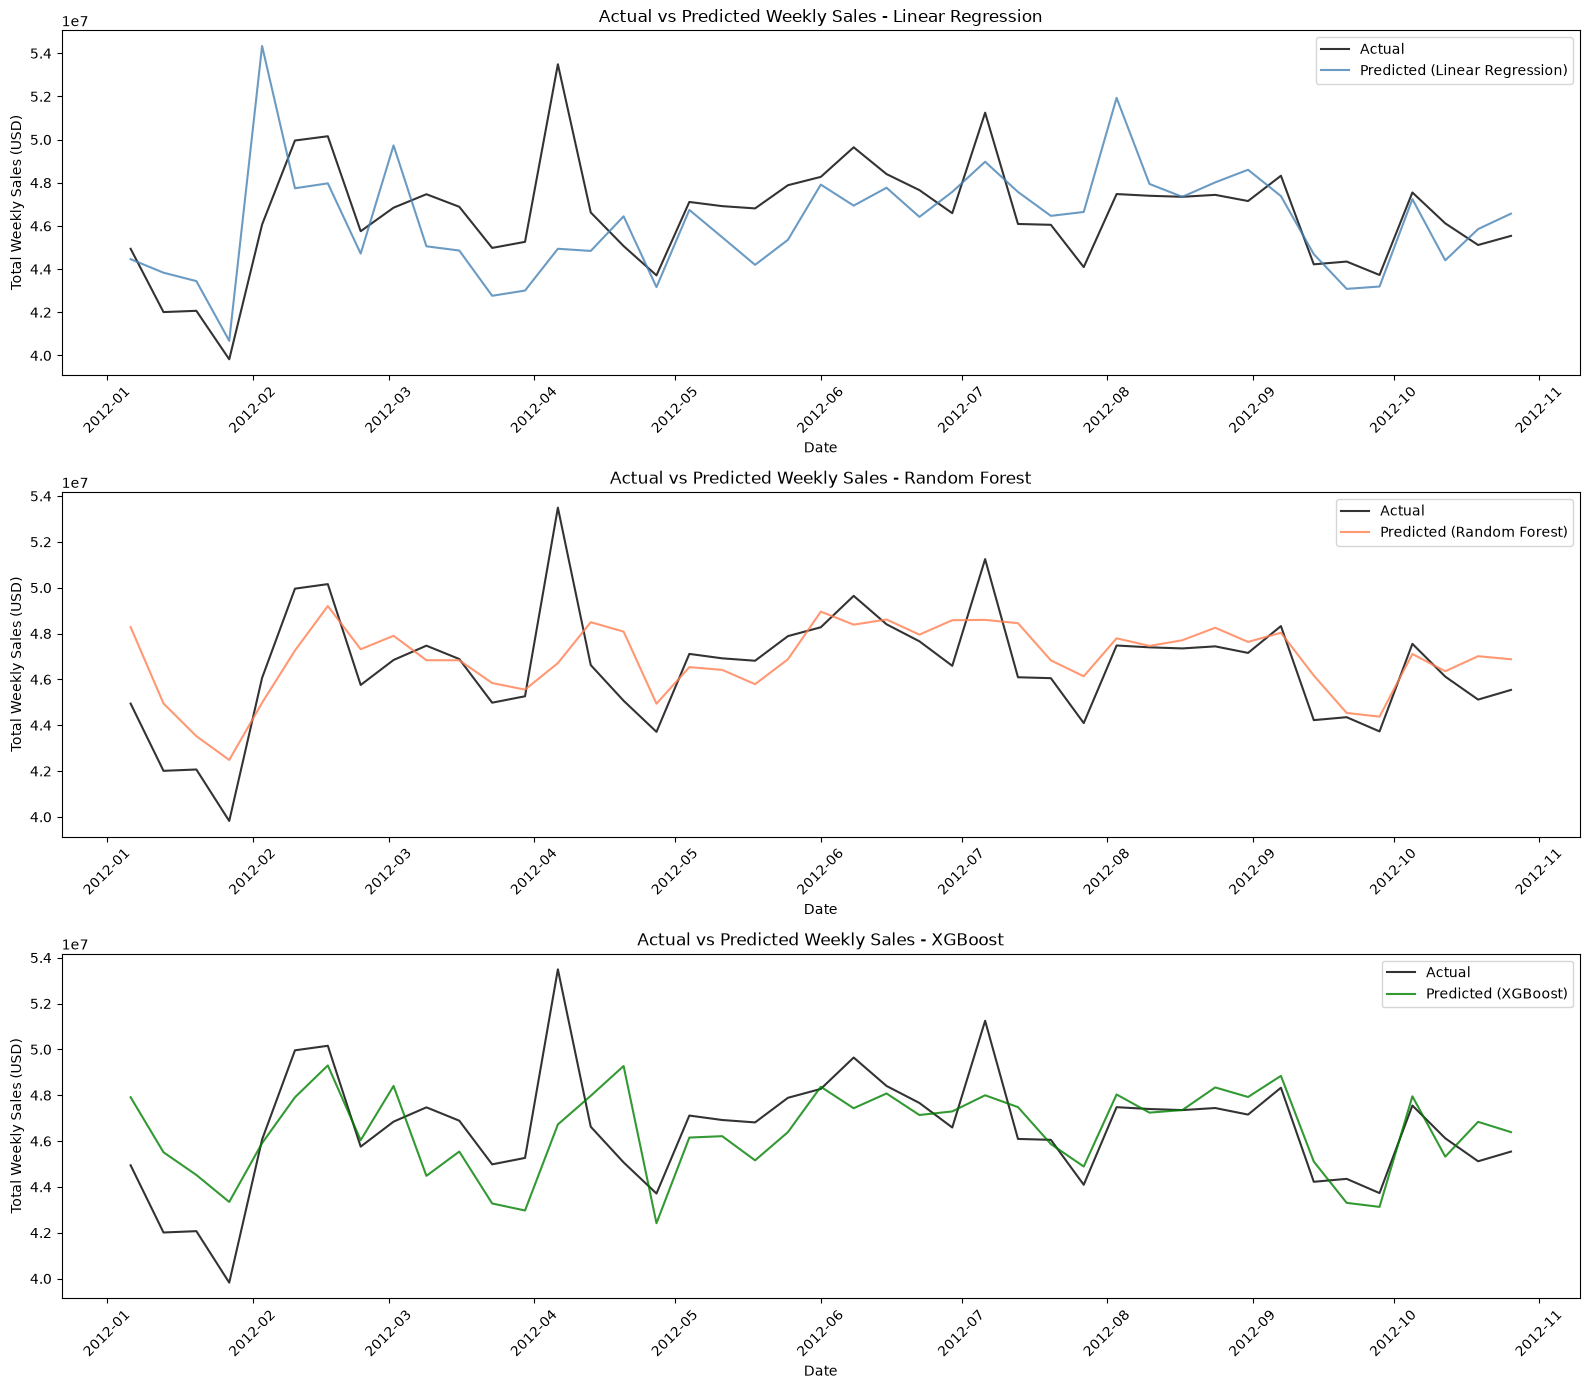

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Aggregate predictions to weekly total for clean visualisation
test_viz = test[['Date']].copy()
test_viz['Actual'] = y_test.values
test_viz['Linear_Regression'] = lr_preds
test_viz['Random_Forest'] = rf_preds
test_viz['XGBoost'] = xgb_preds

weekly_viz = test_viz.groupby('Date').sum().reset_index()

models_viz = [
    ('Linear Regression', 'Linear_Regression', 'steelblue'),
    ('Random Forest', 'Random_Forest', 'coral'),
    ('XGBoost', 'XGBoost', 'green')
]

for i, (name, col, color) in enumerate(models_viz):
    axes[i].plot(weekly_viz['Date'], weekly_viz['Actual'], 
                 color='black', linewidth=1.5, label='Actual', alpha=0.8)
    axes[i].plot(weekly_viz['Date'], weekly_viz[col], 
                 color=color, linewidth=1.5, label=f'Predicted ({name})', alpha=0.8)
    axes[i].set_title(f'Actual vs Predicted Weekly Sales - {name}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Total Weekly Sales (USD)')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

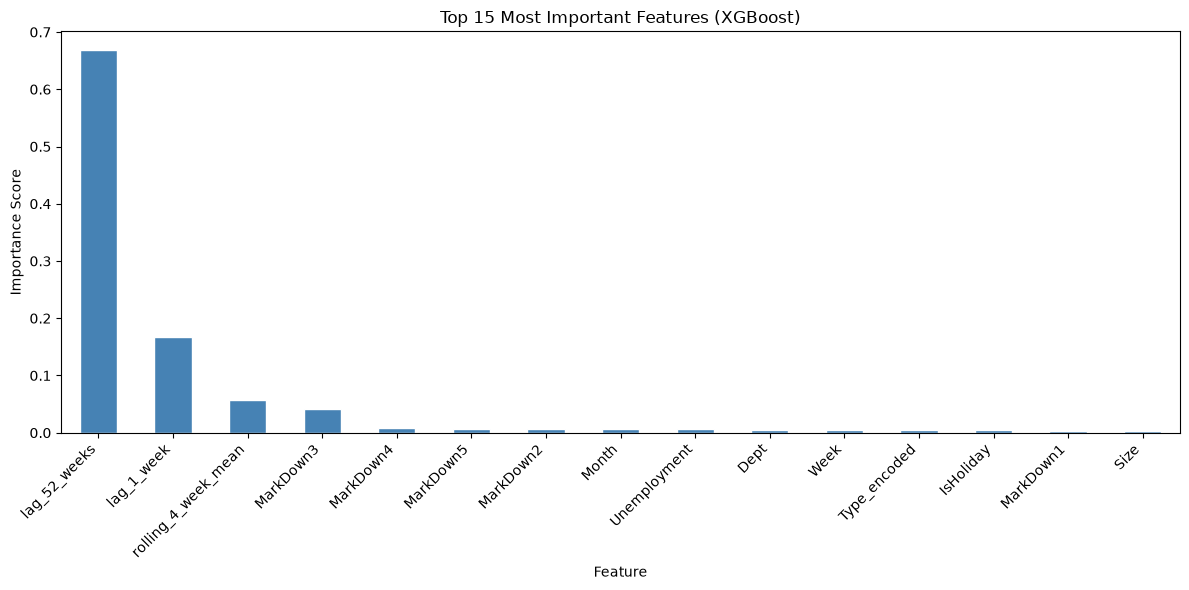

Top 15 features:
lag_52_weeks           0.6678
lag_1_week             0.1664
rolling_4_week_mean    0.0568
MarkDown3              0.0414
MarkDown4              0.0081
MarkDown5              0.0072
MarkDown2              0.0069
Month                  0.0058
Unemployment           0.0058
Dept                   0.0053
Week                   0.0052
Type_encoded           0.0044
IsHoliday              0.0041
MarkDown1              0.0039
Size                   0.0035
dtype: float32


In [16]:
feat_importance = pd.Series(
    xgb.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
feat_importance.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 15 features:")
print(feat_importance.round(4))

## 6. Key Findings

| # | Theme | Finding |
|---|-------|---------|
| 1 | Seasonality | Sales spike significantly in November and December driven by holiday shopping, with a secondary peak around the summer months. |
| 2 | Holiday Impact | Holiday weeks generate noticeably higher sales than non-holiday weeks, confirming that the IsHoliday flag is a useful feature for the model. |
| 3 | Store Type | Type A stores generate significantly higher average weekly sales than Type B and C stores, reflecting differences in store size and location. |
| 4 | Lag Features | The previous week sales (lag 1) and same week last year (lag 52) were the most important features in the XGBoost model, confirming that recent history is the strongest predictor of near-term sales. |
| 5 | Model Performance | XGBoost outperformed both Linear Regression and Random Forest, achieving the lowest MAE and MAPE. Linear Regression struggled with non-linear seasonal patterns. |
| 6 | Chronological Split | Splitting the data by date rather than randomly is critical for honest evaluation. A random split would leak future information into training, inflating performance metrics. |

In [17]:
print("Project Summary:")
print(f"  Total records: {len(df):,}")
print(f"  Stores: {df['Store'].nunique()}")
print(f"  Departments: {df['Dept'].nunique()}")
print(f"  Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Training samples: {len(X_train):,}")
print(f"  Test samples: {len(X_test):,}")
print(f"  Best model: XGBoost")
print(f"  XGBoost MAE: USD {xgb_mae:,.0f}")
print(f"  XGBoost MAPE: {xgb_mape:.2f}%")

Project Summary:
  Total records: 261,083
  Stores: 45
  Departments: 76
  Date range: 2011-02-04 to 2012-10-26
  Training samples: 136,342
  Test samples: 124,741
  Best model: XGBoost
  XGBoost MAE: USD 1,482
  XGBoost MAPE: inf%
